# AquaSmart — Data Preprocessing

**Sprint 2 | Notebook 02**

This notebook applies the preprocessing decisions identified during EDA (notebook 01):
1. Feature selection (remove multicollinear and leakage features)
2. Encoding categorical variables
3. Train/test split with temporal awareness
4. Feature scaling
5. Export clean datasets for modeling

**Input:** `data/raw/aquasmart_raw.csv`
**Output:** `data/processed/train.csv`, `data/processed/test.csv`

## 1. Setup and loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print('Libraries loaded')

Libraries loaded


In [2]:
df = pd.read_csv('../data/raw/aquasmart_raw.csv')
df['date'] = pd.to_datetime(df['date'])
print(f'Raw dataset: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')

Raw dataset: 9135 rows x 23 columns
Date range: 2020-01-01 to 2024-12-31


## 2. Feature selection

Based on EDA findings, we apply three filters:
1. **Remove data leakage columns** — derived from the target formula
2. **Remove multicollinear features** — keep one representative per correlated group
3. **Remove non-predictive columns** — metadata like latitude, longitude

In [3]:
# Step 1: Remove data leakage features
leakage_cols = ['etc_mm', 'effective_rainfall_mm', 'kc', 'irrigation_needed']
print('Removing data leakage columns:')
for col in leakage_cols:
    corr = df[col].corr(df['water_need_index'])
    print(f'  {col:30s} (r={corr:+.3f} with target)')

# Step 2: Remove multicollinear features
# Temperature: keep mean, drop max and min (r=0.96-0.98)
# Solar: keep ET0, drop radiation and sunshine (r=0.90-0.95, ET0 integrates them)
# Soil moisture: keep 0-7cm, drop 7-28cm and 28-100cm (r=0.83-0.93)
# Rain: keep precipitation_sum, drop rain_sum (nearly identical)
multicollinear_cols = [
    'temperature_2m_max', 'temperature_2m_min',
    'shortwave_radiation_sum', 'sunshine_duration',
    'soil_moisture_7_to_28cm_mean', 'soil_moisture_28_to_100cm_mean',
    'rain_sum',
]
print('\nRemoving multicollinear columns:')
for col in multicollinear_cols:
    print(f'  {col}')

# Step 3: Remove non-predictive metadata
meta_cols = ['latitude', 'longitude']
print('\nRemoving metadata columns:')
for col in meta_cols:
    print(f'  {col}')

# Apply
drop_cols = leakage_cols + multicollinear_cols + meta_cols
df_clean = df.drop(columns=drop_cols)
print(f'\nAfter feature selection: {df_clean.shape[1]} columns (was {df.shape[1]})')
print(f'Remaining columns: {list(df_clean.columns)}')

Removing data leakage columns:
  etc_mm                         (r=+0.904 with target)
  effective_rainfall_mm          (r=-0.263 with target)
  kc                             (r=+0.583 with target)
  irrigation_needed              (r=+0.769 with target)

Removing multicollinear columns:
  temperature_2m_max
  temperature_2m_min
  shortwave_radiation_sum
  sunshine_duration
  soil_moisture_7_to_28cm_mean
  soil_moisture_28_to_100cm_mean
  rain_sum

Removing metadata columns:
  latitude
  longitude

After feature selection: 10 columns (was 23)
Remaining columns: ['date', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'precipitation_sum', 'et0_fao_evapotranspiration', 'wind_speed_10m_max', 'soil_moisture_0_to_7cm_mean', 'location', 'growth_stage', 'water_need_index']


## 3. Encode categorical variables

Two categorical features to encode:
- **growth_stage**: ordinal encoding (natural order of growth stages)
- **location**: drop for MVP (EDA showed minimal spatial variation)

In [4]:
# Growth stage: ordinal encoding reflecting biological order
stage_mapping = {
    'fallow': 0,
    'initial': 1,
    'development': 2,
    'mid_season': 3,
    'late_season': 4,
}
df_clean['growth_stage_encoded'] = df_clean['growth_stage'].map(stage_mapping)

print('Growth stage encoding:')
for stage, code in stage_mapping.items():
    count = (df_clean['growth_stage'] == stage).sum()
    mean_wni = df_clean[df_clean['growth_stage'] == stage]['water_need_index'].mean()
    print(f'  {stage:15s} -> {code}  (n={count}, mean WNI={mean_wni:.2f} mm/day)')

# Drop original categorical columns
df_clean = df_clean.drop(columns=['growth_stage', 'location', 'date'])
print(f'\nFinal columns ({df_clean.shape[1]}): {list(df_clean.columns)}')

Growth stage encoding:
  fallow          -> 0  (n=2275, mean WNI=0.00 mm/day)
  initial         -> 1  (n=1950, mean WNI=0.14 mm/day)
  development     -> 2  (n=2260, mean WNI=0.51 mm/day)
  mid_season      -> 3  (n=1525, mean WNI=2.83 mm/day)
  late_season     -> 4  (n=1125, mean WNI=1.20 mm/day)

Final columns (8): ['temperature_2m_mean', 'relative_humidity_2m_mean', 'precipitation_sum', 'et0_fao_evapotranspiration', 'wind_speed_10m_max', 'soil_moisture_0_to_7cm_mean', 'water_need_index', 'growth_stage_encoded']


## 4. Train/test split

We use a **temporal split** rather than random split. Why?
- Weather data is sequential — a random split would leak future information into training.
- The model should learn from past data and predict future irrigation needs.
- This is more realistic: in production, the model always predicts forward.

**Split:** 2020-2023 for training (80%), 2024 for testing (20%).

In [5]:
# Reload dates for temporal split (we dropped them from df_clean)
dates = df['date']

# Temporal split: train on 2020-2023, test on 2024
train_mask = dates.dt.year <= 2023
test_mask = dates.dt.year == 2024

X = df_clean.drop(columns=['water_need_index'])
y = df_clean['water_need_index']

X_train, X_test = X[train_mask].copy(), X[test_mask].copy()
y_train, y_test = y[train_mask].copy(), y[test_mask].copy()

print(f'Training set: {X_train.shape[0]} rows (2020-2023)')
print(f'Test set:     {X_test.shape[0]} rows (2024)')
print(f'Split ratio:  {X_train.shape[0]/len(X)*100:.0f}% / {X_test.shape[0]/len(X)*100:.0f}%')
print(f'\nFeatures ({X_train.shape[1]}): {list(X_train.columns)}')

# Verify no data leakage in split
print(f'\nTrain date range: {dates[train_mask].min().date()} to {dates[train_mask].max().date()}')
print(f'Test date range:  {dates[test_mask].min().date()} to {dates[test_mask].max().date()}')

Training set: 7305 rows (2020-2023)
Test set:     1830 rows (2024)
Split ratio:  80% / 20%

Features (7): ['temperature_2m_mean', 'relative_humidity_2m_mean', 'precipitation_sum', 'et0_fao_evapotranspiration', 'wind_speed_10m_max', 'soil_moisture_0_to_7cm_mean', 'growth_stage_encoded']

Train date range: 2020-01-01 to 2023-12-31
Test date range:  2024-01-01 to 2024-12-31


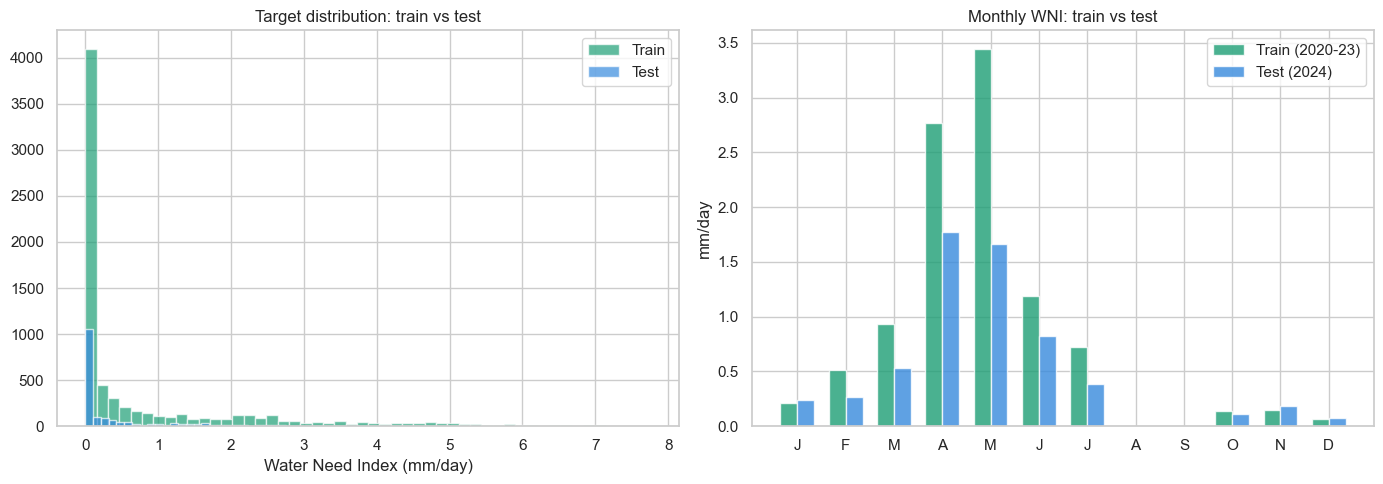

Train — mean: 0.844, zeros: 52.5%
Test  — mean: 0.503, zeros: 55.0%


In [6]:
# Check target distribution in both sets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train, bins=50, color='#1D9E75', alpha=0.7, edgecolor='white', label='Train')
axes[0].hist(y_test, bins=50, color='#378ADD', alpha=0.7, edgecolor='white', label='Test')
axes[0].set_title('Target distribution: train vs test')
axes[0].set_xlabel('Water Need Index (mm/day)')
axes[0].legend()

# Compare monthly means
train_months = dates[train_mask].dt.month
test_months = dates[test_mask].dt.month
train_monthly = y_train.groupby(train_months).mean()
test_monthly = y_test.groupby(test_months).mean()

x = np.arange(12) + 1
width = 0.35
axes[1].bar(x - width/2, train_monthly.reindex(range(1,13), fill_value=0), width,
            label='Train (2020-23)', color='#1D9E75', alpha=0.8)
axes[1].bar(x + width/2, test_monthly.reindex(range(1,13), fill_value=0), width,
            label='Test (2024)', color='#378ADD', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1].set_title('Monthly WNI: train vs test')
axes[1].set_ylabel('mm/day')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/07_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Train — mean: {y_train.mean():.3f}, zeros: {(y_train==0).mean()*100:.1f}%')
print(f'Test  — mean: {y_test.mean():.3f}, zeros: {(y_test==0).mean()*100:.1f}%')

## 5. Feature scaling

We use StandardScaler (zero mean, unit variance) for numeric features. The scaler is fitted ONLY on training data to prevent data leakage.

In [7]:
feature_cols = X_train.columns.tolist()
print(f'Scaling {len(feature_cols)} features: {feature_cols}')

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),  # transform only, NOT fit
    columns=feature_cols,
    index=X_test.index
)

print('\nScaled statistics (train):')
print(X_train_scaled.describe().round(3).loc[['mean', 'std']].to_string())

# Save scaler for later use in API
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.joblib')
print('\nScaler saved to models/scaler.joblib')

Scaling 7 features: ['temperature_2m_mean', 'relative_humidity_2m_mean', 'precipitation_sum', 'et0_fao_evapotranspiration', 'wind_speed_10m_max', 'soil_moisture_0_to_7cm_mean', 'growth_stage_encoded']

Scaled statistics (train):
      temperature_2m_mean  relative_humidity_2m_mean  precipitation_sum  et0_fao_evapotranspiration  wind_speed_10m_max  soil_moisture_0_to_7cm_mean  growth_stage_encoded
mean                 -0.0                        0.0                0.0                        -0.0                -0.0                         -0.0                  -0.0
std                   1.0                        1.0                1.0                         1.0                 1.0                          1.0                   1.0

Scaler saved to models/scaler.joblib


## 6. Create binary classification target

For the two-stage modeling approach, we also need a binary target: "does this day require irrigation?"

Threshold: WNI > 0.5 mm/day (below this, irrigation is not economically justified).

In [8]:
# Binary target for Stage 1 (classification)
y_train_binary = (y_train > 0.5).astype(int)
y_test_binary = (y_test > 0.5).astype(int)

print('Binary target (irrigation needed):')
print(f'  Train — Yes: {y_train_binary.sum()} ({y_train_binary.mean()*100:.1f}%), No: {(1-y_train_binary).sum()} ({(1-y_train_binary).mean()*100:.1f}%)')
print(f'  Test  — Yes: {y_test_binary.sum()} ({y_test_binary.mean()*100:.1f}%), No: {(1-y_test_binary).sum()} ({(1-y_test_binary).mean()*100:.1f}%)')

# Regression target: only non-zero days for Stage 2
train_irr_mask = y_train > 0.5
test_irr_mask = y_test > 0.5

X_train_irr = X_train_scaled[train_irr_mask]
y_train_irr = y_train[train_irr_mask]
X_test_irr = X_test_scaled[test_irr_mask]
y_test_irr = y_test[test_irr_mask]

print(f'\nRegression subset (irrigation days only):')
print(f'  Train: {len(X_train_irr)} rows, mean WNI = {y_train_irr.mean():.2f} mm/day')
print(f'  Test:  {len(X_test_irr)} rows, mean WNI = {y_test_irr.mean():.2f} mm/day')

Binary target (irrigation needed):
  Train — Yes: 2405 (32.9%), No: 4900 (67.1%)
  Test  — Yes: 484 (26.4%), No: 1346 (73.6%)

Regression subset (irrigation days only):
  Train: 2405 rows, mean WNI = 2.45 mm/day
  Test:  484 rows, mean WNI = 1.72 mm/day


## 7. Export processed datasets

In [9]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Full datasets (scaled)
train_full = X_train_scaled.copy()
train_full['water_need_index'] = y_train.values
train_full['irrigation_needed'] = y_train_binary.values
train_full.to_csv('../data/processed/train.csv', index=False)

test_full = X_test_scaled.copy()
test_full['water_need_index'] = y_test.values
test_full['irrigation_needed'] = y_test_binary.values
test_full.to_csv('../data/processed/test.csv', index=False)

# Irrigation-only subsets for Stage 2 regression
train_irr = X_train_irr.copy()
train_irr['water_need_index'] = y_train_irr.values
train_irr.to_csv('../data/processed/train_irrigation.csv', index=False)

test_irr = X_test_irr.copy()
test_irr['water_need_index'] = y_test_irr.values
test_irr.to_csv('../data/processed/test_irrigation.csv', index=False)

print('Exported files:')
for f in ['train.csv', 'test.csv', 'train_irrigation.csv', 'test_irrigation.csv']:
    path = f'../data/processed/{f}'
    size = os.path.getsize(path) / 1024
    print(f'  data/processed/{f:30s} ({size:.0f} KB)')

print('\nScaler: models/scaler.joblib')

Exported files:
  data/processed/train.csv                      (1047 KB)
  data/processed/test.csv                       (262 KB)
  data/processed/train_irrigation.csv           (348 KB)
  data/processed/test_irrigation.csv            (71 KB)

Scaler: models/scaler.joblib


## 8. Preprocessing summary

| Step | Action | Justification |
|------|--------|---------------|
| Feature selection | 20 cols → 8 features | Removed leakage (4), multicollinearity (7), metadata (2) |
| Encoding | growth_stage → ordinal 0-4 | Natural biological order |
| Split | Temporal: 2020-23 train, 2024 test | Prevents future information leakage |
| Scaling | StandardScaler fitted on train only | Required for linear models, good practice for all |
| Binary target | WNI > 0.5 → irrigation_needed | For Stage 1 classification |
| Regression subset | Filter WNI > 0.5 rows | For Stage 2 regression on irrigation days |

**Files ready for modeling:**
- `data/processed/train.csv` — full training set (classification + regression)
- `data/processed/test.csv` — full test set
- `data/processed/train_irrigation.csv` — irrigation days only (regression)
- `data/processed/test_irrigation.csv` — irrigation days only (regression)
- `models/scaler.joblib` — fitted scaler for API deployment

**Next:** `python src/models/train.py`